In [193]:
# Imports
from matplotlib.ticker import FixedLocator, FuncFormatter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [194]:
# Load data
df = pd.read_csv('./data/FinalTransactionReport.csv')

In [195]:
# Examine columns in data
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Event Name: object
Event ID: int64
Event Timestamp: object
Venue Name: object
Transaction Timestamp: object
Price Scale: object
Section: object
Row: object
Seats: object
Primary Seat IDs: object
Average Unit Price: float64
Sales Total: float64
Tickets Sold: int64
Market Place: object
Transaction Type: object
Highest Inventory Price: float64
Lowest Inventory Price: float64
Initial Inventory Price: float64
Event Score: float64
weather_condition: object
temperature_f: float64
precipitation: float64
humidity: int64
weather_category: object
Days Before Event: int64
Start Time: object


In [196]:
team_summary = df.groupby('Event Name', as_index = False).agg(
    NumberOfGames = ('Event ID', 'nunique'),
    TicketsSold = ('Tickets Sold', 'sum'),
    TotalSales = ('Sales Total', 'sum'),
)

team_summary['TicketsPerGame'] = team_summary['TicketsSold'] / team_summary['NumberOfGames']
team_summary['SalesPerGame'] = team_summary['TotalSales'] / team_summary['NumberOfGames']
team_summary['Team Location'] = team_summary['Event Name'].apply(lambda x: x.split(' ')[0])

In [197]:
team_summary

,Event Name,NumberOfGames,TicketsSold,TotalSales,TicketsPerGame,SalesPerGame,Team Location
0,Carolina Mudcats,12,8658,169613.66,721.500000,14134.471667,Carolina
1,Charleston Riverdogs,6,3825,81722.18,637.500000,13620.363333,Charleston
2,Delmarva Shorebirds,9,9413,205186.75,1045.888889,22798.527778,Delmarva
3,Fayetteville Woodpeckers,12,7954,136479.93,662.833333,11373.327500,Fayetteville
4,Kannapolis Cannon Ballers,6,3637,71442.55,606.166667,11907.091667,Kannapolis
5,Lynchburg Hillcats,9,6840,144329.67,760.000000,16036.630000,Lynchburg
6,Salem Red Sox,12,7886,158817.67,657.166667,13234.805833,Salem


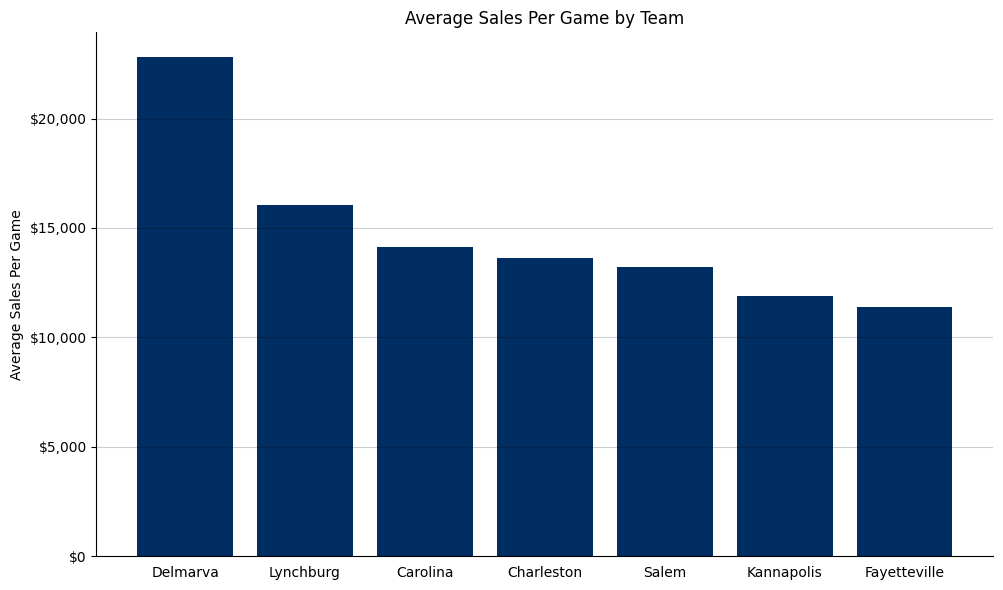

In [198]:
plt.figure(figsize = (10, 6))
team_summary.sort_values(by = 'SalesPerGame', ascending = False, inplace = True)
plt.bar(team_summary['Team Location'], team_summary['SalesPerGame'], color = '#002d62')
plt.ylabel('Average Sales Per Game')
plt.title('Average Sales Per Game by Team')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.tick_params(bottom = False, left = True)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.2, color = 'black', zorder = 0)
plt.gca().yaxis.set_major_locator(FixedLocator(np.arange(0, 100000, 5000)))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.show()

In [199]:
start_time_summary = df.groupby('Start Time', as_index = False).agg(
    NumberOfGames = ('Event ID', 'nunique'),
    TicketsSold = ('Tickets Sold', 'sum'),
    TotalSales = ('Sales Total', 'sum'),
)

start_time_summary['TicketsPerGame'] = start_time_summary['TicketsSold'] / start_time_summary['NumberOfGames']
start_time_summary['SalesPerGame'] = start_time_summary['TotalSales'] / start_time_summary['NumberOfGames']

start_time_summary

,Start Time,NumberOfGames,TicketsSold,TotalSales,TicketsPerGame,SalesPerGame
0,11:05 AM,3,712,14201.79,237.333333,4733.930000
1,1:35 PM,7,7464,153491.54,1066.285714,21927.362857
2,6:05 PM,8,3364,67111.84,420.500000,8388.980000
3,6:35 PM,24,9496,168717.00,395.666667,7029.875000
4,7:05 PM,24,27177,564070.24,1132.375000,23502.926667


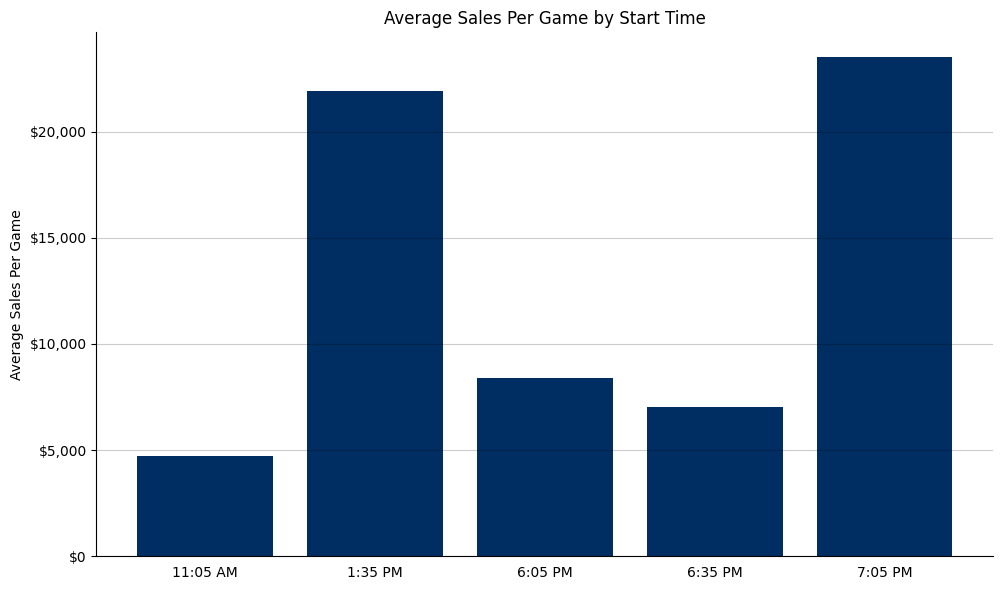

In [200]:
plt.figure(figsize = (10, 6))
start_time_summary.sort_values(by = 'Start Time', ascending = True, inplace = True)
plt.bar(start_time_summary['Start Time'], start_time_summary['SalesPerGame'], color = '#002d62')
plt.ylabel('Average Sales Per Game')
plt.title('Average Sales Per Game by Start Time')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.tick_params(bottom = False, left = True)
plt.grid(axis = 'y', linestyle = '-', alpha = 0.2, color = 'black', zorder = 0)
plt.gca().yaxis.set_major_locator(FixedLocator(np.arange(0, 100000, 5000)))
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.show()

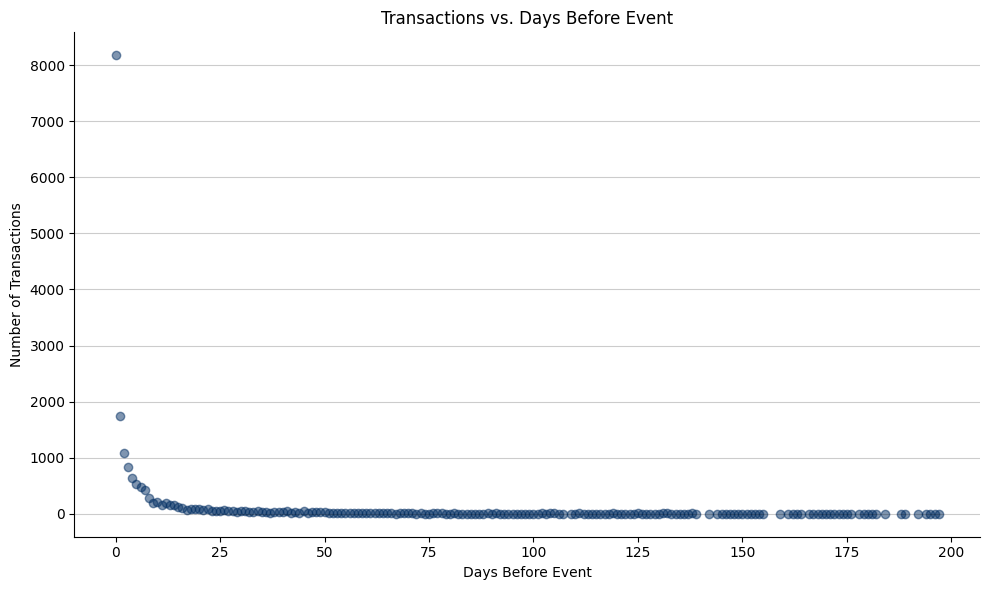

In [201]:
# Count transactions by Days Before Event
days_counts = df.groupby('Days Before Event').size().reset_index(name='Transactions')

plt.figure(figsize=(10, 6))
plt.scatter(days_counts['Days Before Event'], days_counts['Transactions'], alpha=0.5, color='#002d62')
plt.xlabel('Days Before Event')
plt.ylabel('Number of Transactions')
plt.title('Transactions vs. Days Before Event')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.grid(axis='y', linestyle='-', alpha=0.2, color='black', zorder=0)
plt.show()